In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

In [15]:
RECORDS = [
    "100", "101", "105", "106", "108", "109", "111",
    "112", "115", "117", "119", "201", "213", "219"
]

LABEL_MAP = {
    # N — Normal
    "N": "N", ".": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    # S — Supraventricular ectopic
    "A": "S", "a": "S", "J": "S", "S": "S",
    # V — Ventricular ectopic
    "V": "V", "E": "V"
}


In [16]:
records_data = {}

for rec_id in RECORDS:
    record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
    ann = wfdb.rdann(rec_id, "atr", pn_dir="mitdb")
    signal = record.p_signal[:, 0]  # channel 0 (MLII lead)

    records_data[rec_id] = {
        "record": record,
        "ann": ann,
        "signal": signal,
        "fs": record.fs
    }

record_summary = pd.DataFrame([
    {
        "record_id": rec_id,
        "n_samples": len(obj["signal"]),
        "fs": obj["fs"],
        "n_annotations": len(obj["ann"].sample),
        "signal_shape": obj["record"].p_signal.shape
    }
    for rec_id, obj in records_data.items()
]).sort_values("record_id").reset_index(drop=True)

display(record_summary)

,record_id,n_samples,fs,n_annotations,signal_shape
0,100,650000,360,2274,"(650000, 2)"
1,101,650000,360,1874,"(650000, 2)"
2,105,650000,360,2691,"(650000, 2)"
3,106,650000,360,2098,"(650000, 2)"
4,108,650000,360,1824,"(650000, 2)"
5,109,650000,360,2535,"(650000, 2)"
6,111,650000,360,2133,"(650000, 2)"
7,112,650000,360,2550,"(650000, 2)"
8,115,650000,360,1962,"(650000, 2)"
9,117,650000,360,1539,"(650000, 2)"


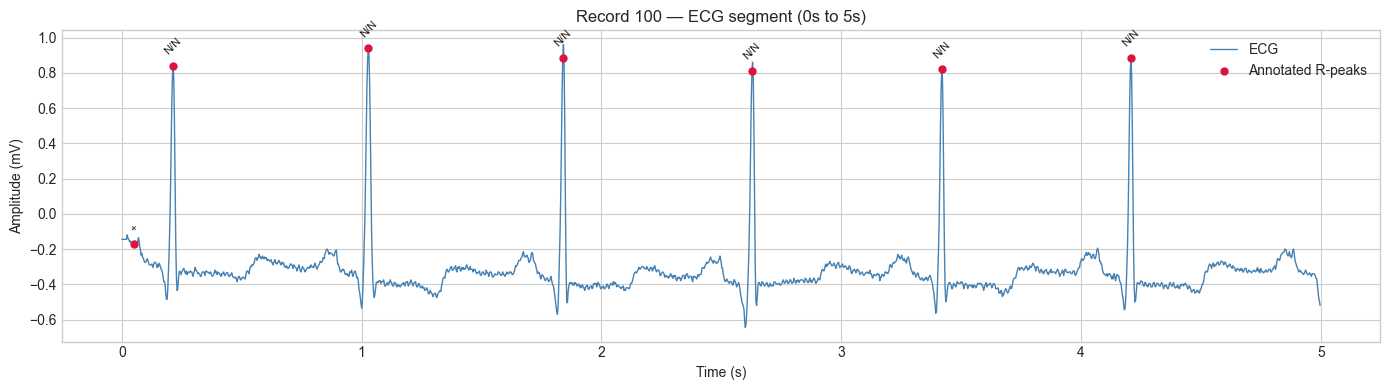

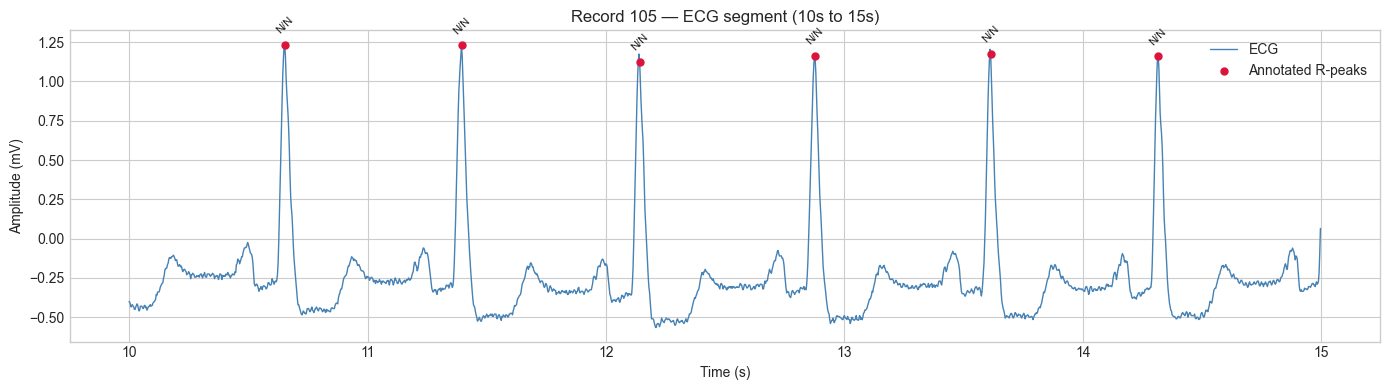

In [18]:
def plot_ecg_segment(records_data, record_id, start_sec=0, duration_sec=5):
    obj = records_data[record_id]
    signal = obj["signal"]
    ann = obj["ann"]
    fs = obj["fs"]

    start_idx = int(start_sec * fs)
    end_idx = int((start_sec + duration_sec) * fs)

    seg_signal = signal[start_idx:end_idx]
    seg_time = np.arange(start_idx, end_idx) / fs

    mask = (ann.sample >= start_idx) & (ann.sample < end_idx)
    peak_samples = ann.sample[mask]
    peak_symbols = np.array(ann.symbol)[mask]

    plt.figure(figsize=(14, 4))
    plt.plot(seg_time, seg_signal, color="steelblue", linewidth=1.0, label="ECG")
    plt.scatter(
        peak_samples / fs,
        signal[peak_samples],
        color="crimson",
        s=25,
        zorder=3,
        label="Annotated R-peaks"
    )

    for s, sym in zip(peak_samples, peak_symbols):
        mapped = LABEL_MAP.get(sym, "discard")
        text = f"{sym}/{mapped}" if mapped != "discard" else sym
        plt.annotate(
            text,
            (s / fs, signal[s]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            rotation=45
        )

    plt.title(f"Record {record_id} — ECG segment ({start_sec}s to {start_sec + duration_sec}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# You can change start_sec if you want a cleaner or more interesting segment.
plot_ecg_segment(records_data, "100", start_sec=0, duration_sec=5)
plot_ecg_segment(records_data, "105", start_sec=10, duration_sec=5)

,class,count
0,N,28412
1,S,206
2,V,1544


/var/folders/hm/sn1nc66j7cb6zsr6j3gzs4wh0000gn/T/ipykernel_1530/3954744149.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="class", y="count", palette="viridis")
/Users/mac/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mac/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicit

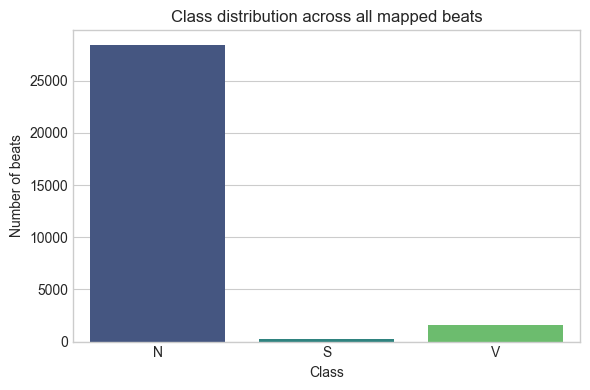

Total mapped beats: 30162
Total discarded annotations: 1057

Discarded counts by raw symbol:


,raw_symbol,count
0,F,369
1,+,252
2,~,196
3,x,181
4,|,48
5,Q,7
6,"""",4


In [20]:
mapped_rows = []
discard_rows = []

for rec_id, obj in records_data.items():
    ann = obj["ann"]

    for sample_idx, raw_symbol in zip(ann.sample, ann.symbol):
        mapped_label = LABEL_MAP.get(raw_symbol)

        if mapped_label is None:
            discard_rows.append({
                "record_id": rec_id,
                "sample": int(sample_idx),
                "raw_symbol": raw_symbol
            })
        else:
            mapped_rows.append({
                "record_id": rec_id,
                "sample": int(sample_idx),
                "raw_symbol": raw_symbol,
                "label": mapped_label
            })

mapped_beats_df = pd.DataFrame(mapped_rows)
discarded_df = pd.DataFrame(discard_rows)

class_counts = (
    mapped_beats_df["label"]
    .value_counts()
    .reindex(["N", "S", "V"], fill_value=0)
    .rename_axis("class")
    .reset_index(name="count")
)

display(class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(data=class_counts, x="class", y="count", palette="viridis")
plt.title("Class distribution across all mapped beats")
plt.xlabel("Class")
plt.ylabel("Number of beats")
plt.tight_layout()
plt.show()

print("Total mapped beats:", len(mapped_beats_df))
print("Total discarded annotations:", len(discarded_df))

if not discarded_df.empty:
    discarded_by_symbol = (
        discarded_df.groupby("raw_symbol")
        .size()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    discarded_by_record_symbol = (
        discarded_df.groupby(["record_id", "raw_symbol"])
        .size()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )

    print("\nDiscarded counts by raw symbol:")
    display(discarded_by_symbol.head(20))


The MIT-BIH dataset exhibits severe class imbalance, with N beats comprising ~85-90% of all beats. S and V beats together account for only 10-15%.

Implications for modelling:

  • A naïve classifier predicting 'N' always would achieve ~87% accuracy a misleading metric that masks total failure on clinically critical classes.
  
  • False negatives on V (ventricular ectopic) beats are especially dangerous: missing a PVC or ventricular escape beat can have fatal consequences.
  
  • Recommended metrics:
  
      – Macro-averaged F1: treats every class equally regardless of size.
      
      – Per-class recall for S and V: directly measures sensitivity to rare events.
      
      – Weighted F1 gives a secondary picture (overall balance).
      
 